##### Phase 1: Data Ingestion & Clinical Sanitation

Load diabetic_data.csv file into a pandas dataframe

In [153]:
import pandas as pd
import numpy as np
import csv

df = pd.read_csv('./diabetic_data.csv')
print(df)

        encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        Caucasian    Male  [70-80)      ?   

        admission_type_id  discharge_disposition_id  admission_

Perform an initial audit

Check dataframe length, datatypes of the columns and non-null value count of columns

In [154]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Identify numberic columns and get their summary of statistics includes count, mean, standard deviation, minimum, quartiles (25%, 50%, 75%), and maximum

In [155]:
print(df.describe())

       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             7.00000

Retrieve the default first 5 rows from the dataframe to understand the overall structure of the diabetic data

In [156]:
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

Get dataframe columns

In [157]:
print(df.columns);

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


Replace the ? character with the standard NumPy NaN value, '?' is used by hospitals to represent empty or null values

In [158]:
df = df.replace('?',np.nan)
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)    NaN   
1             149190     55629189        Caucasian  Female  [10-20)    NaN   
2              64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3             500364     82442376        Caucasian    Male  [30-40)    NaN   
4              16680     42519267        Caucasian    Male  [40-50)    NaN   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)    NaN   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)    NaN   
101763     443854148     41088789        Caucasian    Male  [70-80)    NaN   
101764     443857166     31693671        Caucasian  Female  [80-90)    NaN   
101765     443867222    175429310        Caucasian    Male  [70-80)    NaN   

        admission_type_id  discharge_disposition_id  admission_

Drop the column entirely if the missingness exceeds 90%

In [159]:
missing_percent_of_each_columns = df.isna().mean()*100
print(missing_percent_of_each_columns);

df = df.dropna(axis=1,thresh=len(df)*0.1)
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

Load IDs_mapping.csv file into a pandas dataframe

In [160]:
id_df = pd.read_csv('./IDs_mapping.csv')
print(id_df)

   admission_type_id                                        description
0                  1                                          Emergency
1                  2                                             Urgent
2                  3                                           Elective
3                  4                                            Newborn
4                  5                                      Not Available
..               ...                                                ...
62                22   Transfer from hospital inpt/same fac reslt in...
63                23                          Born inside this hospital
64                24                         Born outside this hospital
65                25            Transfer from Ambulatory Surgery Center
66                26                              Transfer from Hospice

[67 rows x 2 columns]


Get discharge_disposition_id codes corresponding 'Expired'

In [161]:
expired_rows = id_df[id_df['description'].str.contains('Expired', na=False)]
expired_rows['admission_type_id'] = expired_rows['admission_type_id'].astype(int)
print(expired_rows)

expired_ids = expired_rows['admission_type_id'].to_list()
print(expired_ids)

    admission_type_id                                        description
20                 11                                            Expired
28                 19           Expired at home. Medicaid only, hospice.
29                 20  Expired in a medical facility. Medicaid only, ...
30                 21    Expired, place unknown. Medicaid only, hospice.
[11, 19, 20, 21]


C:\Users\PCWORLD\AppData\Local\Temp\ipykernel_16748\3202125533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expired_rows['admission_type_id'] = expired_rows['admission_type_id'].astype(int)


Remove dead records and filter only possible readmissions

In [162]:
df = df[~df['discharge_disposition_id'].isin(expired_ids)]
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

Remove deplicates entries

In [163]:
df = df.drop_duplicates();
print(df);

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

##### Phase 2 – Web Scraping & Data Enrichment

Calculate the frequency of all codes in diag_1

In [164]:
group_by_obj = df.groupby(by='diag_1')
frequency = group_by_obj.diag_1.count()
print(frequency)

diag_1
10      1
11     10
110     2
112    72
114     1
       ..
V63     7
V66     2
V67     1
V70     1
V71     9
Name: diag_1, Length: 715, dtype: int64


Sort frequency by decending order to identify top frequent disease codes

In [165]:
sored_frequency = frequency.sort_values(ascending=False)
print(sored_frequency)

diag_1
428    6735
414    6555
786    4016
410    3477
486    3413
       ... 
974       1
114       1
976       1
V67       1
V70       1
Name: diag_1, Length: 715, dtype: int64


Find top 20 most frequency disease codes

In [166]:
top_disease_code = sored_frequency.head(n=20)
print(top_disease_code)

diag_1
428      6735
414      6555
786      4016
410      3477
486      3413
427      2729
491      2252
715      2147
682      2030
780      2012
434      1958
996      1944
276      1861
250.8    1667
599      1581
38       1522
584      1482
V57      1204
250.6    1178
820      1075
Name: diag_1, dtype: int64


Choose ICD-9 lookup resource as https://www.icd9data.com

https://www.icd9data.com website does not provide direct URLs for individual codes. Code pages are stored inside multiple nested folders based on volume and code ranges. So array of main ranges and sub-ranges is created. When sending requests based on code, find the main range and subrange, and dynamically create a URL to send the request to retrieve the web page

In [167]:
main_ranges = [
    "001-139",
    "140-239",
    "240-279",
    "280-289",
    "290-319",
    "320-389",
    "390-459",
    "460-519",
    "520-579",
    "580-629",
    "630-679",
    "680-709",
    "710-739",
    "740-759",
    "760-779",
    "780-799",
    "800-999",
    "V01-V91",
    "E000-E999"
]

In [168]:
sub_range = [
    # Symptoms, Signs, And Ill-Defined Conditions 780-799
    "780-789",
    "790-796",
    "797-799",

    # Mental Disorders 290-319
    "290-294",
    "295-299",
    "300-316",
    "317-319",

    # Diseases Of The Genitourinary System 580-629
    "580-589",
    "590-599",
    "600-608",
    "610-612",
    "614-616",
    "617-629",

    # Complications Of Pregnancy, Childbirth, And The Puerperium 630-679
    "630-639",
    "640-649",
    "650-659",
    "660-669",
    "670-677",
    "678-679",

    # Certain Conditions Originating In The Perinatal Period 760-779
    "760-763",
    "764-779",

    # Diseases Of The Skin And Subcutaneous Tissue 680-709
    "680-686",
    "690-698",
    "700-709",

    # Diseases Of The Circulatory System 390-459
    "390-392",
    "393-398",
    "401-405",
    "410-414",
    "415-417",
    "420-429",
    "430-438",
    "440-449",
    "451-459",

    # Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders 240-279
    "240-246",
    "249-259",
    "260-269",
    "270-279",

    # Diseases Of The Musculoskeletal System And Connective Tissue 710-739
    "710-719",
    "720-724",
    "725-729",
    "730-739",

    # Diseases Of The Digestive System 520-579
    "520-529",
    "530-539",
    "540-543",
    "550-553",
    "555-558",
    "560-569",
    "570-579",

    # Diseases Of The Nervous System And Sense Organs 320-389
    "320-327",
    "330-337",
    "338-338",
    "339-339",
    "340-349",
    "350-359",
    "360-379",
    "380-389",

    # Injury And Poisoning 800-999 (main chapter ranges shown)
    "800-804",
    "805-809",
    "810-819",
    "820-829",
    "830-839",
    "840-848",
    "850-854",
    "860-869",
    "870-879",
    "880-887",
    "890-897",
    "900-904",
    "905-909",
    "910-919",
    "920-924",
    "925-929",
    "930-939",
    "940-949",
    "950-957",
    "958-959",
    "960-979",
    "980-989",
    "990-995",
    "996-999",

    # Neoplasms 140-239
    "140-149",
    "150-159",
    "160-165",
    "170-176",
    "179-189",
    "190-199",
    "200-209",
    "210-229",
    "230-234",
    "235-238",
    "239-239",

    # Supplementary Classification Of Factors Influencing Health Status... V01-V91
    "V01-V09",
    "V10-V19",
    "V20-V29",
    "V30-V39",
    "V40-V49",
    "V50-V59",
    "V60-V69",
    "V70-V82",
    "V83-V84",
    "V85-V85",
    "V86-V86",
    "V87-V87",
    "V88-V88",
    "V89-V89",
    "V90-V90",
    "V91-V91",

    # Diseases Of The Respiratory System 460-519
    "460-466",
    "470-478",
    "480-488",
    "490-496",
    "500-508",
    "510-519",

    # Infectious And Parasitic Diseases 001-139
    "001-009",
    "010-018",
    "020-027",
    "030-041",
    "042-042",
    "045-049",
    "050-059",
    "060-066",
    "070-079",
    "080-088",
    "090-099",
    "100-104",
    "110-118",
    "120-129",
    "130-136",
    "137-139",

    # Supplementary Classification Of External Causes Of Injury And Poisoning E000-E999
    "E000-E000",
    "E001-E030",
    "E800-E807",
    "E810-E819",
    "E820-E825",
    "E826-E829",
    "E830-E838",
    "E840-E845",
    "E846-E849",
    "E850-E858",
    "E860-E869",
    "E870-E876",
    "E878-E879",
    "E880-E888",
    "E890-E899",
    "E900-E909",
    "E910-E915",
    "E916-E928",
    "E929-E929",
    "E930-E949",
    "E950-E959",
    "E960-E969",
    "E970-E979",
    "E980-E989",
    "E990-E999"
]

Function for sending requests to retrieve web pages of corresponding codes and exact disease names

In [169]:
import requests
from bs4 import BeautifulSoup
import time

disease_code_name_map = {};

def get_deasese_names():
    for x in  top_disease_code.keys():

        code = x;
        if len(code) == 2:
            code = '0'+code
        
        prefix = code.split(".")[0]

        p = code.split(".")[0]
        if len(p) == 2:
            p = '0'+p

        if prefix.startswith('V') or prefix.startswith('E'):
            prefix = int(prefix[1:])
        else:
            prefix = int(prefix)

        for a in main_ranges:

            found = False

            range = a
        
            first = range.split('-')[0]
            f = range.split('-')[0]
            if first.startswith('V') or first.startswith('E'):
                first = int(first[1:])
            else:
                first = int(first)
            
            second = range.split('-')[1]
            s = range.split('-')[1]
            if second.startswith('V') or second.startswith('E'):
                second = int(second[1:])
            else:
                second = int(second)

            m_range = ''

            if x.startswith('V') and f.startswith('V') and s.startswith('V'):
                if prefix >= first and prefix <= second:
                    m_range = a
            
                    for b in sub_range:
                        range_b = b
        
                        first_b = range_b.split('-')[0]
                        f_b = range_b.split('-')[0]
                        if first_b.startswith('V') or first_b.startswith('E'):
                            first_b = int(first_b[1:])
                        else:
                            first_b = int(first_b)
            
                        second_b = range_b.split('-')[1]
                        s_b = range_b.split('-')[1]
                        if second_b.startswith('V') or second_b.startswith('E'):
                            second_b = int(second_b[1:])
                        else:
                            second_b = int(second_b)
            
                        s_range = ''

                        if x.startswith('V') and f_b.startswith('V') and s_b.startswith('V'):
                            if prefix >= first_b and prefix <= second_b:
                                s_range = b
                                found = True
                                break


            elif x.startswith('E') and f.startswith('E') and s.startswith('E'):
                if prefix >= first and prefix <= second:
                    m_range = a
            
                    for b in sub_range:
                        range_b = b
        
                        first_b = range_b.split('-')[0]
                        f_b = range_b.split('-')[0]
                        if first_b.startswith('V') or first_b.startswith('E'):
                            first_b = int(first_b[1:])
                        else:
                            first_b = int(first_b)
            
                        second_b = range_b.split('-')[1]
                        s_b = range_b.split('-')[1]
                        if second_b.startswith('V') or second_b.startswith('E'):
                            second_b = int(second_b[1:]);
                        else:
                            second_b = int(second_b)
            
                        s_range = ''

                        if x.startswith('E') and f_b.startswith('E') and s_b.startswith('E'):
                            if prefix >= first_b and prefix <= second_b:
                                s_range = b
                                found = True
                                break

            elif not x.startswith('V') and not f.startswith('V') and not s.startswith('V') and not x.startswith('E') and not f.startswith('E') and not s.startswith('E'):
                if prefix >= first and prefix <= second:
                    m_range = a
            
                    for b in sub_range:
                        range_b = b
        
                        first_b = range_b.split('-')[0]
                        f_b = range_b.split('-')[0]
                        if first_b.startswith('V') or first_b.startswith('E'):
                            first_b = int(first_b[1:])
                        else:
                            first_b = int(first_b)
            
                        second_b = range_b.split('-')[1]
                        s_b = range_b.split('-')[1]
                        if second_b.startswith('V') or second_b.startswith('E'):
                            second_b = int(second_b[1:])
                        else:
                            second_b = int(second_b)
            
                        s_range = ''

                        if not x.startswith('V') and not f_b.startswith('V') and not s_b.startswith('V') and not x.startswith('E') and not f_b.startswith('E') and not s_b.startswith('E'):
                            if prefix >= first_b and prefix <= second_b:
                                s_range = b
                                found = True
                                break
        
            if found:
                break
            
        print('code', x)
        print('main range',m_range)
        print('sub range',s_range)
        print('------')

        if s_range == '':
            print(f'https://www.icd9data.com/2015/Volume1/{m_range}/{s_range}/{p}/{code}.htm')
            response = requests.get(f'https://www.icd9data.com/2015/Volume1/{m_range}/{p}/{code}.htm')
            html_doc = response.text
            soup = BeautifulSoup(html_doc,'html.parser')
            t = soup.find('title').text
            disease = t.split(':')[1].strip()
            print(disease)

            disease_code_name_map[x] = disease

            time.sleep(1)

        else:
            print(f'https://www.icd9data.com/2015/Volume1/{m_range}/{s_range}/{p}/{code}.htm')
            response = requests.get(f'https://www.icd9data.com/2015/Volume1/{m_range}/{s_range}/{p}/{code}.htm')
            html_doc = response.text
            soup = BeautifulSoup(html_doc,'html.parser')
            t = soup.find('title').text
            disease = t.split(':')[1].strip()
            print(disease)

            disease_code_name_map[x] = disease

            time.sleep(1)


get_deasese_names()

print(disease_code_name_map)

code 428
main range 390-459
sub range 420-429
------
https://www.icd9data.com/2015/Volume1/390-459/420-429/428/428.htm
Heart failure
code 414
main range 390-459
sub range 410-414
------
https://www.icd9data.com/2015/Volume1/390-459/410-414/414/414.htm
Other forms of chronic ischemic heart disease
code 786
main range 780-799
sub range 780-789
------
https://www.icd9data.com/2015/Volume1/780-799/780-789/786/786.htm
Symptoms involving respiratory system and other chest symptoms
code 410
main range 390-459
sub range 410-414
------
https://www.icd9data.com/2015/Volume1/390-459/410-414/410/410.htm
Acute myocardial infarction
code 486
main range 460-519
sub range 480-488
------
https://www.icd9data.com/2015/Volume1/460-519/480-488/486/486.htm
Pneumonia, organism unspecified
code 427
main range 390-459
sub range 420-429
------
https://www.icd9data.com/2015/Volume1/390-459/420-429/427/427.htm
Cardiac dysrhythmias
code 491
main range 460-519
sub range 490-496
------
https://www.icd9data.com/2015

Create new column named "Primary_Diagnosis_Desc" by mapping disease name with "diag_1" code

In [170]:
df["Primary_Diagnosis_Desc"] = (
    df["diag_1"].map(disease_code_name_map)
    )
print(df)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

Replace "Primary_Diagnosis_Desc" column NaN values with "Other"

In [171]:
df["Primary_Diagnosis_Desc"].replace(np.nan,'Other',inplace=True)
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

C:\Users\PCWORLD\AppData\Local\Temp\ipykernel_16748\3597213428.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Primary_Diagnosis_Desc"].replace(np.nan,'Other',inplace=True)


##### Phase 4: Feature Engineering - The "Vitality Complexity Index"

Create a new column "VCI_Score" by calculating the score for each patient based on the columns "time_in_hospital", "admission_type_id", "number_diagnoses", and "number_emergency"

In [172]:
def calculate_length_of_stay_score(days_count):
    L = 0
    if pd.isna(days_count):
        L = 0
    elif days_count < 1:
        L = 0
    elif days_count >= 1 and days_count <= 4:
        L = 1
    elif days_count >= 5 and days_count <= 13:
        L = 4
    elif days_count >= 14:
        L = 7
    return L

def calculate_acuity_of_admission_score(id):
    A = 0
    if pd.isna(id):
        A = 0
    elif id == 1 or id == 7:
        A = 3
    else:
        A = 0
    return A

def calculate_comorbidity_burden_score(diagnoses_count):
    C = 0
    if pd.isna(diagnoses_count):
        C = 0
    elif diagnoses_count < 4:
        C = 0
    elif diagnoses_count >= 4 and diagnoses_count <= 7:
        C = 3
    elif diagnoses_count >= 8:
        C = 5
    return C

def calculate_emergency_visit_intensity_score(visits_count):
    E = 0
    if pd.isna(visits_count):
        E = 0
    elif visits_count <= 0:
        E = 0
    elif visits_count >= 1 and visits_count <= 4:
        E = 3
    elif visits_count > 4:
        E = 5
    return E


df['VCI_Score'] = df['time_in_hospital'].apply(calculate_length_of_stay_score) + df['admission_type_id'].apply(calculate_acuity_of_admission_score) + df['number_diagnoses'].apply(calculate_comorbidity_burden_score) + df['number_emergency'].apply(calculate_emergency_visit_intensity_score)
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

Create a new column "Risk_Category" based on the "VCI_Score"

In [173]:
def get_risk_category(score):
    if score < 7:
        return 'Low Risk'
    elif score >= 7 and score <= 10:
        return 'Medium Risk'
    elif score > 10:
        return 'High Risk'


df['Risk_Category'] = df['VCI_Score'].apply(get_risk_category)
print(df)

# write to csv file
df.to_csv('df.csv', index=False)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

Calculate the "Low Risk" patients readmission rate

In [174]:
low_risk_patients = df[df['Risk_Category'] == 'Low Risk']
print(low_risk_patients)

low_risk_patients_readmitted = df[(df['Risk_Category'] == 'Low Risk') & (df['readmitted'] == '<30')]
print(low_risk_patients_readmitted)

low_risk_patient_readmisson_rate = len(low_risk_patients_readmitted) / len(low_risk_patients)*100
print(low_risk_patient_readmisson_rate)

        encounter_id  patient_nbr             race  gender      age  \
0            2278392      8222157        Caucasian  Female   [0-10)   
5              35754     82637451        Caucasian    Male  [50-60)   
6              55842     84259809        Caucasian    Male  [60-70)   
14             62256     49726791  AfricanAmerican  Female  [60-70)   
17             84222    108662661        Caucasian  Female  [50-60)   
...              ...          ...              ...     ...      ...   
101740     443778398    134647673        Caucasian    Male  [40-50)   
101742     443787512     52419276        Caucasian    Male  [70-80)   
101745     443797076    183766055        Caucasian    Male  [50-60)   
101750     443824292    138784172        Caucasian  Female  [80-90)   
101752     443835512    139605341            Other  Female  [40-50)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                       6                        25                    

Calculate the "Medium Risk" patients readmission rate

In [175]:
medium_risk_patients = df[df['Risk_Category'] == 'Medium Risk']
print(medium_risk_patients)

medium_risk_patients_readmitted = df[(df['Risk_Category'] == 'Medium Risk') & (df['readmitted'] == '<30')]
print(medium_risk_patients_readmitted)

medium_risk_patient_readmisson_rate = len(medium_risk_patients_readmitted) / len(medium_risk_patients)*100
print(medium_risk_patient_readmisson_rate)

        encounter_id  patient_nbr             race  gender      age  \
1             149190     55629189        Caucasian  Female  [10-20)   
2              64410     86047875  AfricanAmerican  Female  [20-30)   
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
8              12522     48330783        Caucasian  Female  [80-90)   
...              ...          ...              ...     ...      ...   
101751     443835140    175326800        Caucasian    Male  [70-80)   
101759     443842778     86472243        Caucasian    Male  [80-90)   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
1                       1                         1                    

Calculate the "High Risk" patients readmission rate

In [176]:
high_risk_patients = df[df['Risk_Category'] == 'High Risk']
print(high_risk_patients)

high_risk_patients_readmitted = df[(df['Risk_Category'] == 'High Risk') & (df['readmitted'] == '<30')]
print(high_risk_patients_readmitted)

high_risk_patient_readmisson_rate = len(high_risk_patients_readmitted) / len(high_risk_patients)*100
print(high_risk_patient_readmisson_rate)

        encounter_id  patient_nbr             race  gender      age  \
7              63768    114882984        Caucasian    Male  [70-80)   
10             28236     89869032  AfricanAmerican  Female  [40-50)   
12             40926     85504905        Caucasian  Female  [40-50)   
13             42570     77586282        Caucasian    Male  [80-90)   
15             73578     86328819  AfricanAmerican    Male  [60-70)   
...              ...          ...              ...     ...      ...   
101757     443842136    181593374        Caucasian  Female  [70-80)   
101758     443842340    120975314        Caucasian  Female  [80-90)   
101760     443847176     50375628  AfricanAmerican  Female  [60-70)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
7                       1                         1                    

Create a chart to visualize the readmission rate (<30 days) for each of the three risk categories

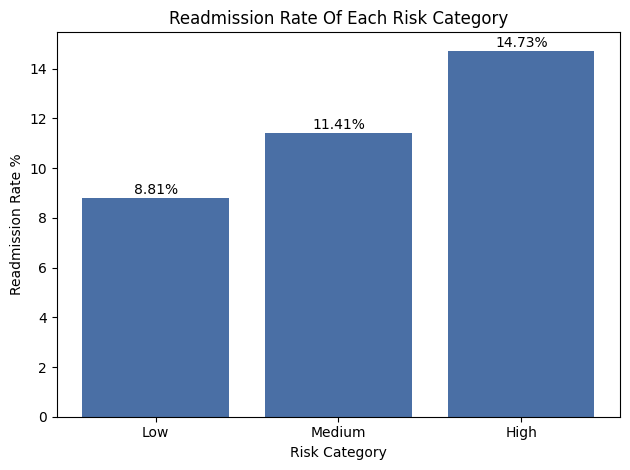

In [177]:
import matplotlib.pyplot as plt

categories = ['Low', 'Medium', 'High']
values = [low_risk_patient_readmisson_rate,
          medium_risk_patient_readmisson_rate,
          high_risk_patient_readmisson_rate]

plt.bar(categories, values, color='#4A6FA5')

for i, v in enumerate(values):
    plt.text(i, v + 0.01 * max(values), f"{v:.2f}%", ha='center', fontsize=10)

plt.title('Readmission Rate Of Each Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Readmission Rate %')

plt.tight_layout()
plt.show()


##### Phase 3: Exploratory Data Analysis (EDA)

Generate a count plot for the readmitted variable (NO, >30, <30)

In [178]:
y = [];

not_readmitted_patients_count = len(df[df['readmitted'] == 'NO'])
print(not_readmitted_patients_count)
y.append(not_readmitted_patients_count)

readmitted_patients_after_30_days_count = len(df[df['readmitted'] == '>30'])
print(readmitted_patients_after_30_days_count)
y.append(readmitted_patients_after_30_days_count)

readmitted_patients_before_30_days_count = len(df[df['readmitted'] == '<30'])
print(readmitted_patients_before_30_days_count)
y.append(readmitted_patients_before_30_days_count)

print(y)

53212
35545
11357
[53212, 35545, 11357]


In [179]:
x = ['NO','>30','<30']

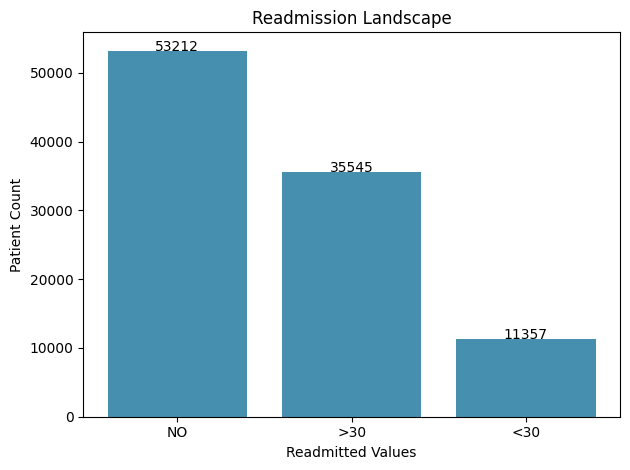

In [180]:
plt.bar(x, y, color='#468FAF')

for i, v in enumerate(y):
    plt.text(i, v, f"{v}", ha='center', fontsize=10)

plt.title('Readmission Landscape')
plt.xlabel('Readmitted Values')
plt.ylabel('Patient Count')

plt.tight_layout()
plt.show()

Visualize the age distribution

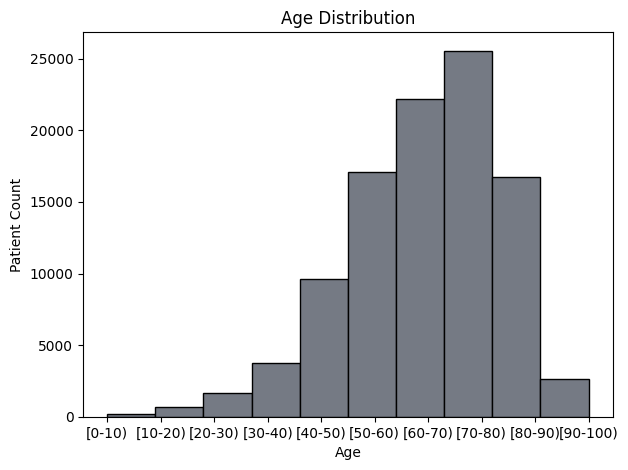

In [181]:
plt.hist(df['age'],bins=10,color="#757A84",edgecolor='#000000');

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Patient Count')

plt.tight_layout();
plt.show();

Visualize readmission by race and gender

{'AfricanAmerican-Female': 11.27, 'AfricanAmerican-Male': 7.41, 'Asian-Female': 0.21, 'Asian-Male': 0.36, 'Caucasian-Female': 39.55, 'Caucasian-Male': 34.97, 'Hispanic-Female': 0.87, 'Hispanic-Male': 0.97, 'Other-Female': 0.67, 'Other-Male': 0.59, 'Other-Unknown/Invalid': 0.0}


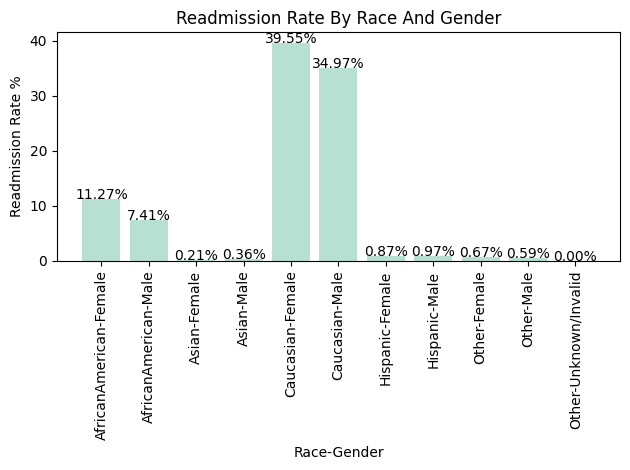

In [182]:
obj = df.groupby(by=['race','gender'])
patient_counts_each_groups = obj.gender.count().values
each_groups_label = obj.gender.count().index.values

i = 0
rates = {}

for (race,gender) in each_groups_label:
    readmitted_count = len(df[(df['race'] == race) & (df['gender'] == gender) & (df['readmitted'] == '<30')])
    rate = float(round(readmitted_count/patient_counts_each_groups[0]*100,2))
    rates[race+'-'+gender] = rate

print(rates)

plt.bar(rates.keys(), rates.values(), color='#B8E0D2')

for i, v in enumerate(rates.values()):
    plt.text(i, v, f"{v:.2f}%", ha='center', fontsize=10)

plt.title('Readmission Rate By Race And Gender')
plt.xlabel('Race-Gender')
plt.ylabel('Readmission Rate %')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Compare readmission rates by medication type (Insulin vs Oral meds vs No meds)

In [183]:
med_groups = ['Insulin', 'Oral Meds', 'No Meds']
rates = {}

total_insulin = len(df[df['insulin'] != 'No'])
total_oral = len(df[(df['diabetesMed'] == 'Yes') & (df['insulin'] == 'No')])
total_none = len(df[df['diabetesMed'] == 'No'])

readmit_insulin = len(df[(df['insulin'] != 'No') & (df['readmitted'] == '<30')])
readmit_oral = len(df[(df['diabetesMed'] == 'Yes') & (df['insulin'] == 'No') & (df['readmitted'] == '<30')])
readmit_none = len(df[(df['diabetesMed'] == 'No') & (df['readmitted'] == '<30')])

rates['Insulin'] = round((readmit_insulin / total_insulin) * 100, 2)
rates['Oral Meds'] = round((readmit_oral / total_oral) * 100, 2)
rates['No Meds'] = round((readmit_none / total_none) * 100, 2)

print(rates)

{'Insulin': 12.35, 'Oral Meds': 10.53, 'No Meds': 9.83}


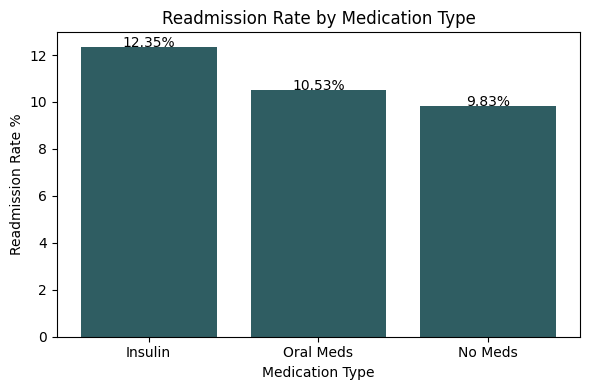

In [184]:
plt.figure(figsize=(6,4))
plt.bar(rates.keys(), rates.values(), color='#2F5D62')

for i, v in enumerate(rates.values()):
    plt.text(i, v, f"{v}%", ha='center', fontsize=10)

plt.title('Readmission Rate by Medication Type')
plt.xlabel('Medication Type')
plt.ylabel('Readmission Rate %')

plt.tight_layout()
plt.show()


Analyze medication changes

In [185]:
change_yes_patients_count = len(df[df['change'] == 'Ch'])
change_yes_patients_count_readmitted_count = len(df[(df['change'] == 'Ch') & (df['readmitted'] == '<30')])
change_yes_patients_readmitted_rate = round(change_yes_patients_count_readmitted_count/change_yes_patients_count*100,2)
print(change_yes_patients_readmitted_rate)

change_no_patients_count = len(df[df['change'] == 'No'])
change_no_patients_count_readmitted_count = len(df[(df['change'] == 'No') & (df['readmitted'] == '<30')])
change_no_patients_readmitted_rate = round(change_no_patients_count_readmitted_count/change_no_patients_count*100,2)
print(change_no_patients_readmitted_rate)


11.97
10.8


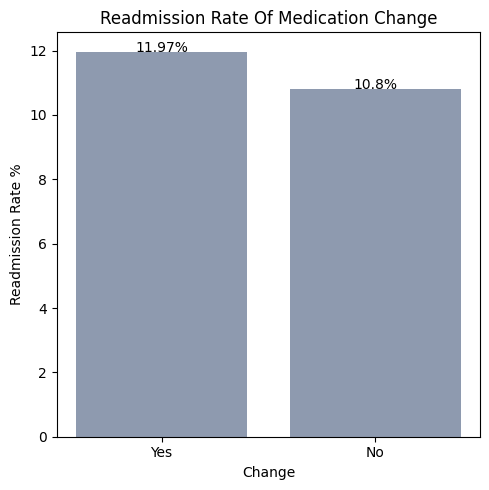

In [186]:
plt.figure(figsize=(5, 5))
plt.bar(['Yes','No'], [change_yes_patients_readmitted_rate,change_no_patients_readmitted_rate], color="#8E9AAF", width=0.8)

for i, v in enumerate([change_yes_patients_readmitted_rate,change_no_patients_readmitted_rate]):
    plt.text(i, v, f"{v}%", ha='center', fontsize=10)

plt.title('Readmission Rate Of Medication Change')
plt.xlabel('Change')
plt.ylabel('Readmission Rate %')

plt.tight_layout()
plt.show()

Visualize the relationship between time_in_hospital and num_lab_procedures

In [187]:
obj = df.groupby(by='time_in_hospital')

lab_count = obj.num_lab_procedures.count()
lab_sum = obj.num_lab_procedures.sum()

avg_lab = lab_sum / lab_count

print(avg_lab)

time_in_hospital
1     32.621559
2     37.553723
3     40.257951
4     43.701924
5     46.628534
6     48.411852
7     50.000696
8     51.287069
9     53.203280
10    53.409607
11    54.169154
12    54.568879
13    55.647911
14    55.240869
Name: num_lab_procedures, dtype: float64


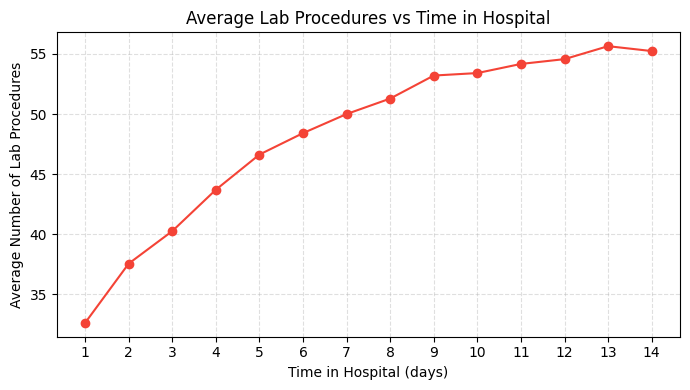

In [188]:
plt.figure(figsize=(7,4))
plt.plot(avg_lab.index, avg_lab.values, marker='o', color='#F44336')

plt.title('Average Lab Procedures vs Time in Hospital')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Average Number of Lab Procedures')

plt.xticks(range(avg_lab.index.min(), avg_lab.index.max() + 1))
# plt.ylim(bottom=0)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Investigate if readmitted patients had longer stays and more outliers

In [189]:
no_readmit = df[df['readmitted'] == 'NO']['time_in_hospital']
lt30_readmit = df[df['readmitted'] == '<30']['time_in_hospital']

C:\Users\PCWORLD\AppData\Local\Temp\ipykernel_16748\2319146755.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


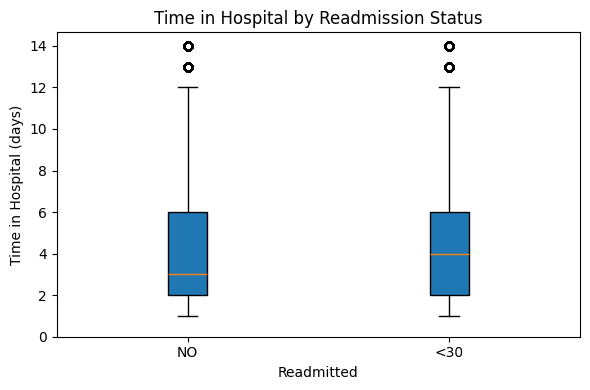

In [190]:
plt.figure(figsize=(6,4))

plt.boxplot(
    [no_readmit, lt30_readmit],
    labels=['NO', '<30'],
    patch_artist=True
)

plt.title('Time in Hospital by Readmission Status')
plt.xlabel('Readmitted')
plt.ylabel('Time in Hospital (days)')

plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


Compare readmission rates for patients discharged to “Home” vs “Skilled Nursing Facilities (SNF)

In [191]:
home_total = len(df[df['discharge_disposition_id'] == 1])
home_readmit = len(df[(df['discharge_disposition_id'] == 1) & (df['readmitted'] == '<30')])
home_rate = round((home_readmit / home_total) * 100, 2)

snf_total = len(df[df['discharge_disposition_id'] == 3])
snf_readmit = len(df[(df['discharge_disposition_id'] == 3) & (df['readmitted'] == '<30')])
snf_rate = round((snf_readmit / snf_total) * 100, 2)

rates = {'Home': home_rate, 'Skilled Nursing Facility': snf_rate}

print(rates)

{'Home': 9.3, 'Skilled Nursing Facility': 14.66}


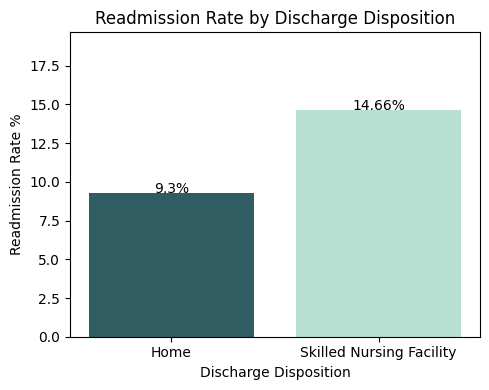

In [192]:
plt.figure(figsize=(5,4))
plt.bar(rates.keys(), rates.values(), color=['#2F5D62', '#B8E0D2'])

for i, v in enumerate(rates.values()):
    plt.text(i, v, f"{v}%", ha='center', fontsize=10)

plt.title('Readmission Rate by Discharge Disposition')
plt.xlabel('Discharge Disposition')
plt.ylabel('Readmission Rate %')
plt.ylim(0, max(rates.values()) + 5)  # start from 0
plt.tight_layout()
plt.show()


Correlation heatmap of numerical features

In [193]:
numerical_features = ['num_medications', 'num_lab_procedures', 'time_in_hospital']
df_num = df[numerical_features]

corr_matrix = df_num.corr()
print(corr_matrix)

                    num_medications  num_lab_procedures  time_in_hospital
num_medications            1.000000            0.265123          0.464082
num_lab_procedures         0.265123            1.000000          0.319754
time_in_hospital           0.464082            0.319754          1.000000


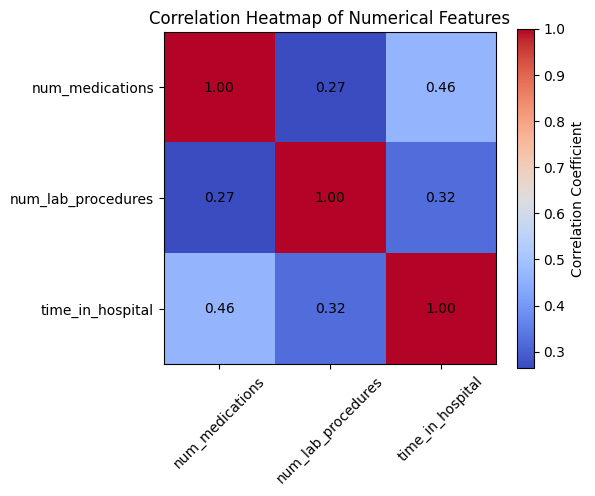

In [194]:
plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(numerical_features)), numerical_features, rotation=45)
plt.yticks(range(len(numerical_features)), numerical_features)

for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()
